# ATML Assignment 0 — Task 2: Understanding Self-Attention & Vision Transformers

**Course:** EE-5102/CS-6304 Advanced Topics in Machine Learning
**Deadline:** 20 August 2026 · Pass/Fail · Individual submission

This notebook covers **Task 2** end-to-end: pretrained-ViT classification, patch
attention visualization, attention-map analysis, patch-masking robustness, and
CLS-token vs. mean-pooled linear probes.

### Design notes (read before running — same conventions as the Task 1 notebook)
- **Model:** `google/vit-base-patch16-224` from Hugging Face (ImageNet-21k pretrained,
  fine-tuned on ImageNet-1k). Patch size 16 on 224×224 images gives exactly the
  14×14 = 196-patch grid the assignment PDF works through, so attention maps line up
  with the PDF's example without any extra reshaping logic.
- **Resumability:** this task is mostly inference (no long gradient-descent training
  loops), so instead of per-epoch checkpoints the resumable unit is a *cached
  computation*: extracted embeddings are saved to `.npz`, fitted linear probes are
  saved with `joblib`, and the patch-masking sweep in Part 4 appends one row per
  (fraction, strategy) to a CSV and **skips any row already computed** — so a crash
  mid-sweep just picks up where it left off on re-run.
- **Shared dataset cache:** CIFAR-10 is downloaded to a `shared_data/` folder one
  level above the per-task folders, so Task 3 and Task 4 notebooks can reuse it
  instead of re-downloading. If you already ran the Task 1 notebook, note that it
  stored its own CIFAR-10 copy under `Task1_ResNet152/data/` — this notebook uses the
  shared copy instead, so CIFAR-10 will download once more here (~170MB) unless you
  repoint `CIFAR_DIR` at Task 1's folder.
- **Methodology choice for Parts 4 & 5:** the pretrained model's classification head
  outputs ImageNet-1k logits (1000 classes), which don't line up with CIFAR-10's 10
  labels — there's no clean way to score "accuracy" from those logits directly against
  CIFAR-10. So for the masking-robustness and CLS-vs-mean-pooling experiments, this
  notebook extracts **frozen embeddings** from the ViT backbone and trains a small
  **linear probe** (10-way logistic regression) on top, the same pattern used for
  Task 1's ResNet feature-quality comparison. This is standard practice for probing
  representation quality and keeps the two experiments cleanly comparable. Worth a
  sentence in your report explaining this choice.


## 0. Setup

In [ ]:
!pip -q install transformers --upgrade


In [1]:
import os, time, math, random
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms

from transformers import ViTImageProcessor, ViTForImageClassification

print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)
import transformers
print("transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())


torch: 2.11.0+cu128 | torchvision: 0.26.0+cu128
transformers: 5.13.1
CUDA available: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ASSIGNMENT_BASE  = "/content/drive/MyDrive/ATML_A0"
SHARED_DATA_DIR  = os.path.join(ASSIGNMENT_BASE, "shared_data")
TASK_DIR         = os.path.join(ASSIGNMENT_BASE, "Task2_ViT")

CKPT_DIR    = os.path.join(TASK_DIR, "checkpoints")
LOG_DIR     = os.path.join(TASK_DIR, "logs")
FIG_DIR     = os.path.join(TASK_DIR, "figures")
FEATURE_DIR = os.path.join(TASK_DIR, "features")
IMAGE_DIR   = os.path.join(TASK_DIR, "sample_images")
CIFAR_DIR   = os.path.join(SHARED_DATA_DIR, "cifar10")

for d in [SHARED_DATA_DIR, CKPT_DIR, LOG_DIR, FIG_DIR, FEATURE_DIR, IMAGE_DIR, CIFAR_DIR]:
    os.makedirs(d, exist_ok=True)

print("Task artifacts will persist under:", TASK_DIR)
print("Shared datasets under:", SHARED_DATA_DIR)


Mounted at /content/drive
Task artifacts will persist under: /content/drive/MyDrive/ATML_A0/Task2_ViT
Shared datasets under: /content/drive/MyDrive/ATML_A0/shared_data


In [3]:
# ----------------------------- CONFIG --------------------------------------
SEED = 42
MODEL_NAME = "google/vit-base-patch16-224"

PROBE_TRAIN_SIZE = 2000   # CIFAR-10 images used to fit the linear probes
PROBE_TEST_SIZE  = 1000   # CIFAR-10 images used to evaluate them
MASK_EVAL_SUBSET = 500    # CIFAR-10 test images used in the masking sweep (Part 4)
MASK_FRACTIONS   = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9]
MASK_STRATEGIES  = ["random", "center"]
BATCH_SIZE = 32
# -----------------------------------------------------------------------------

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

set_seed(SEED)
DEVICE = get_device()
print("Using device:", DEVICE)


Using device: cuda


## 1. Resumable-computation utilities

Same spirit as Task 1's checkpointing, adapted to inference-heavy work: cache
expensive one-shot computations (feature extraction, fitted probes) to Drive, and
make the multi-row masking sweep skip rows it has already computed.

In [4]:
def append_history_row(csv_path: str, row: dict):
    df_row = pd.DataFrame([row])
    header = not os.path.exists(csv_path)
    df_row.to_csv(csv_path, mode="a", header=header, index=False)

def load_history(csv_path: str) -> pd.DataFrame:
    if os.path.exists(csv_path):
        return pd.read_csv(csv_path)
    return pd.DataFrame()

def row_already_done(df: pd.DataFrame, **key_cols) -> bool:
    if df.empty:
        return False
    mask = pd.Series(True, index=df.index)
    for k, v in key_cols.items():
        mask &= (df[k] == v)
    return bool(mask.any())

def train_or_load_probe(cache_path, X_train, y_train, max_iter=2000):
    from sklearn.linear_model import LogisticRegression
    if os.path.exists(cache_path):
        print(f"Loaded cached probe: {cache_path}")
        return joblib.load(cache_path)
    clf = LogisticRegression(max_iter=max_iter).fit(X_train, y_train)
    joblib.dump(clf, cache_path)
    return clf


## 2. Load the pretrained ViT

In [30]:
# ============================================================
# 2. Load the pretrained ViT
# ============================================================

# IMPORTANT:
# We explicitly use eager attention because Part 2 needs
# output_attentions=True. SDPA does not return attention maps
# with output_attentions=True in the current Transformers version.

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager"
)

model.eval().to(DEVICE)

PATCH_SIZE = model.config.patch_size
IMG_SIZE   = model.config.image_size
GRID_SIZE  = IMG_SIZE // PATCH_SIZE
NUM_HEADS  = model.config.num_attention_heads
NUM_LAYERS = model.config.num_hidden_layers
HIDDEN_DIM = model.config.hidden_size

print(f"{MODEL_NAME}")
print(
    f"  patch_size={PATCH_SIZE}  "
    f"image_size={IMG_SIZE}  "
    f"grid={GRID_SIZE}x{GRID_SIZE} "
    f"({GRID_SIZE * GRID_SIZE} patches)"
)
print(
    f"  heads={NUM_HEADS}  "
    f"layers={NUM_LAYERS}  "
    f"hidden_dim={HIDDEN_DIM}"
)
print(
    f"  image_mean={processor.image_mean}  "
    f"image_std={processor.image_std}"
)
print("  attention implementation: eager")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

google/vit-base-patch16-224
  patch_size=16  image_size=224  grid=14x14 (196 patches)
  heads=12  layers=12  hidden_dim=768
  image_mean=(0.5, 0.5, 0.5)  image_std=(0.5, 0.5, 0.5)
  attention implementation: eager


In [31]:
# A transform matching the processor's own normalization, for batched CIFAR-10 loading
# later (Parts 4 & 5) — avoids per-image processor calls inside a DataLoader.
vit_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(processor.image_mean, processor.image_std),
])

def unnormalize_for_display(pixel_values_single, mean=processor.image_mean, std=processor.image_std):
    """pixel_values_single: (3, H, W) tensor already normalized -> displayable (H, W, 3) array
    in [0, 1]. Reconstructing the display image FROM pixel_values (rather than resizing the
    original PIL image separately) guarantees it's pixel-aligned with whatever the model saw,
    which matters for overlaying attention maps correctly."""
    img = pixel_values_single.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)


## 3. Part 1 — Using a Pretrained ViT for Image Classification

Two well-known, stable sample images (so this cell works identically for everyone):
a dog photo from the official PyTorch Hub examples, and the COCO validation image of
two cats on a couch used throughout the Hugging Face docs.

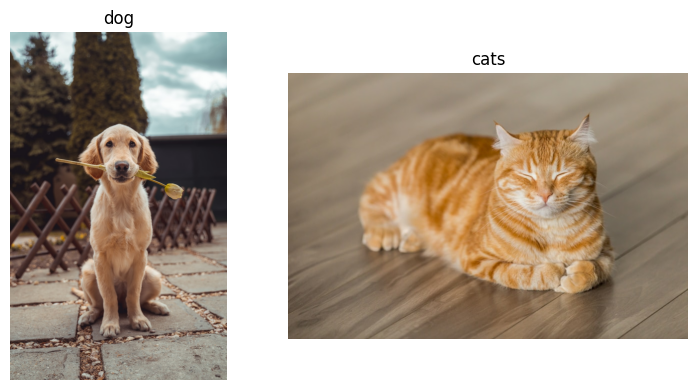

In [32]:
import os
import requests
import matplotlib.pyplot as plt
from PIL import Image

SAMPLE_IMAGES = {
    "dog": "https://images.unsplash.com/photo-1552053831-71594a27632d?w=800",
    "cats": "https://images.unsplash.com/photo-1519052537078-e6302a4968d4?w=800",
}

image_paths = {}

headers = {
    "User-Agent": "Mozilla/5.0"
}

for name, url in SAMPLE_IMAGES.items():
    dst = os.path.join(IMAGE_DIR, f"{name}.jpg")

    if not os.path.exists(dst):
        print(f"Downloading {name}...")

        response = requests.get(
            url,
            headers=headers,
            timeout=30
        )
        response.raise_for_status()

        with open(dst, "wb") as f:
            f.write(response.content)

    image_paths[name] = dst

pil_images = {
    name: Image.open(path).convert("RGB")
    for name, path in image_paths.items()
}

fig, axes = plt.subplots(
    1,
    len(pil_images),
    figsize=(4 * len(pil_images), 4)
)

for ax, (name, img) in zip(axes, pil_images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "part1_sample_images.png"),
    dpi=150
)

plt.show()

In [33]:
@torch.no_grad()
def classify_image(pil_image, topk=5):
    inputs = processor(images=pil_image, return_tensors="pt").to(DEVICE)
    outputs = model(**inputs)
    probs = outputs.logits.softmax(dim=-1)[0]
    top_probs, top_idx = probs.topk(topk)
    return [(model.config.id2label[i.item()], p.item()) for p, i in zip(top_probs, top_idx)]

PREDICTIONS_LOG = os.path.join(LOG_DIR, "part1_predictions.csv")
prediction_rows = []
for name, img in pil_images.items():
    top5 = classify_image(img, topk=5)
    print(f"\n{name}.jpg — top-5 predictions:")
    for label, prob in top5:
        print(f"  {prob:.3f}  {label}")
    top1_label, top1_prob = top5[0]
    prediction_rows.append({"image": name, "top1_label": top1_label, "top1_prob": top1_prob})

pd.DataFrame(prediction_rows).to_csv(PREDICTIONS_LOG, index=False)
pd.read_csv(PREDICTIONS_LOG)



dog.jpg — top-5 predictions:
  0.860  golden retriever
  0.121  Labrador retriever
  0.003  tennis ball
  0.001  flat-coated retriever
  0.001  Sussex spaniel

cats.jpg — top-5 predictions:
  0.567  tiger cat
  0.234  tabby, tabby cat
  0.149  Egyptian cat
  0.006  Persian cat
  0.002  lens cap, lens cover


,image,top1_label,top1_prob
0,dog,golden retriever,0.860167
1,cats,tiger cat,0.566538


## 4. Part 2 — Visualizing Patch Attention

Extract the final layer's attention, average over heads, take the CLS token's
attention to all 196 patch tokens, reshape to the 14×14 grid, upsample, and overlay
on the exact 224×224 pixels the model processed.

In [34]:
# ============================================================
# Part 2 — Extract CLS Attention
# ============================================================

@torch.no_grad()
def get_cls_attention_map(pil_image):
    """
    Returns:
        pixel_values:
            (1, 3, H, W)

        attn_map_grid:
            (GRID_SIZE, GRID_SIZE), averaged across heads
            from the final transformer layer

        all_layer_attentions:
            tuple containing attention tensors for every layer
            with shape (1, heads, sequence_length, sequence_length)
    """

    inputs = processor(
        images=pil_image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    outputs = model(
        **inputs,
        output_attentions=True
    )

    attentions = outputs.attentions

    # Safety check
    if attentions is None or len(attentions) == 0:
        raise RuntimeError(
            "No attention maps were returned. "
            "Make sure the model was loaded with "
            "attn_implementation='eager'."
        )

    # Final transformer layer
    last_layer_attn = attentions[-1][0]

    # Shape:
    # (NUM_HEADS, sequence_length, sequence_length)
    assert last_layer_attn.shape[0] == NUM_HEADS

    # CLS token is token 0.
    # Tokens 1: contain the 196 image patches.
    cls_to_patches = last_layer_attn[:, 0, 1:]

    # Shape:
    # (NUM_HEADS, 196)
    assert cls_to_patches.shape[1] == GRID_SIZE * GRID_SIZE

    # Average attention across heads
    avg_attn = cls_to_patches.mean(dim=0)

    # Reshape 196 patches -> 14 x 14 grid
    attn_grid = (
        avg_attn
        .reshape(GRID_SIZE, GRID_SIZE)
        .cpu()
        .numpy()
    )

    return (
        inputs["pixel_values"],
        attn_grid,
        attentions
    )


def overlay_attention(
    pixel_values,
    attn_grid,
    title,
    save_path=None,
    alpha=0.5
):
    display_img = unnormalize_for_display(pixel_values[0])

    attn_t = torch.tensor(
        attn_grid,
        dtype=torch.float32
    )[None, None]

    attn_up = F.interpolate(
        attn_t,
        size=(IMG_SIZE, IMG_SIZE),
        mode="bilinear",
        align_corners=False
    )[0, 0].numpy()

    attn_up = (
        (attn_up - attn_up.min())
        / (attn_up.max() - attn_up.min() + 1e-8)
    )

    plt.figure(figsize=(5, 5))

    plt.imshow(display_img)

    plt.imshow(
        attn_up,
        cmap="jet",
        alpha=alpha
    )

    plt.title(title)
    plt.axis("off")

    if save_path:
        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight"
        )

    plt.show()

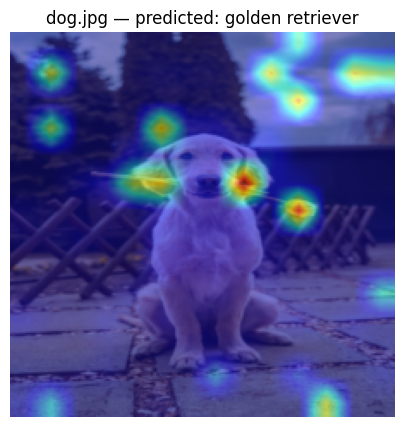

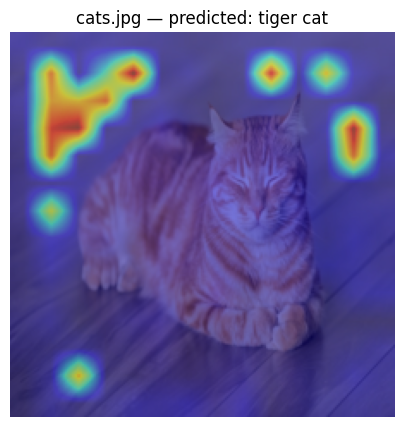

In [35]:
attention_cache = {}
for name, img in pil_images.items():
    pixel_values, attn_grid, all_attn = get_cls_attention_map(img)
    attention_cache[name] = {"pixel_values": pixel_values, "attn_grid": attn_grid, "all_attn": all_attn}
    top1_label = classify_image(img, topk=1)[0][0]
    overlay_attention(pixel_values, attn_grid, title=f"{name}.jpg — predicted: {top1_label}",
                       save_path=os.path.join(FIG_DIR, f"part2_attention_overlay_{name}.png"))


## 5. Part 3 — Analyze the Attention Map

Also checks whether individual heads in the final layer are specialized, by plotting
each head's CLS attention map separately — visually distinct heads (some tightly
focused, some diffuse, some drawn to different regions) is evidence of specialization;
near-identical maps across heads would suggest redundancy instead.


dog.jpg
  Number of heads: 12
  Number of patches: 196
  Patch grid: 14 x 14
Saved: /content/drive/MyDrive/ATML_A0/Task2_ViT/figures/part3_all_heads_dog.png


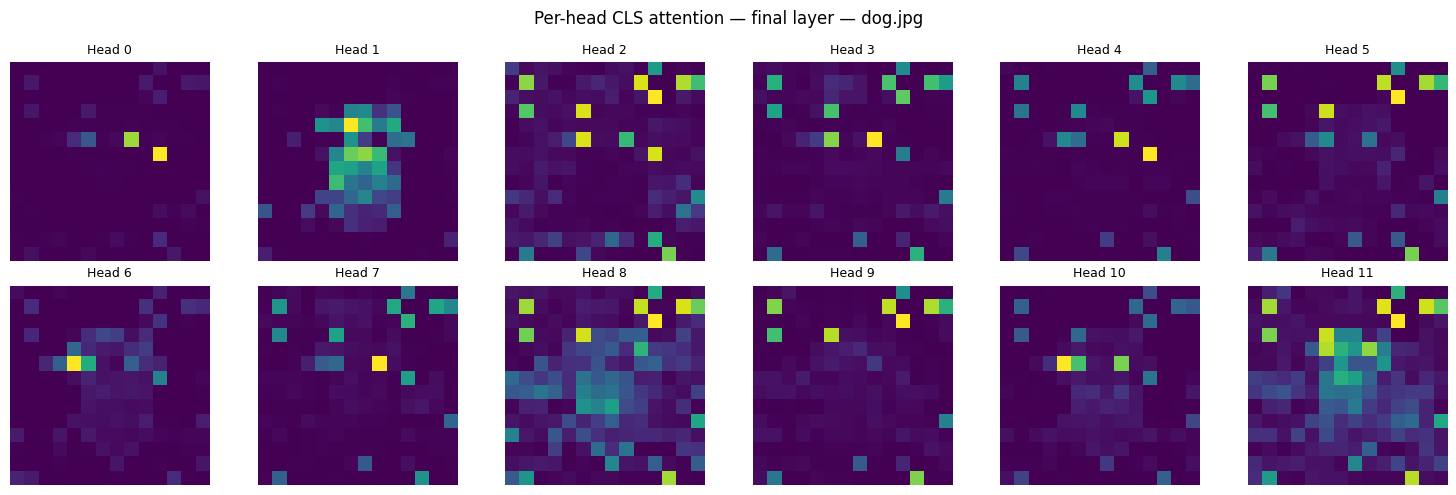


cats.jpg
  Number of heads: 12
  Number of patches: 196
  Patch grid: 14 x 14
Saved: /content/drive/MyDrive/ATML_A0/Task2_ViT/figures/part3_all_heads_cats.png


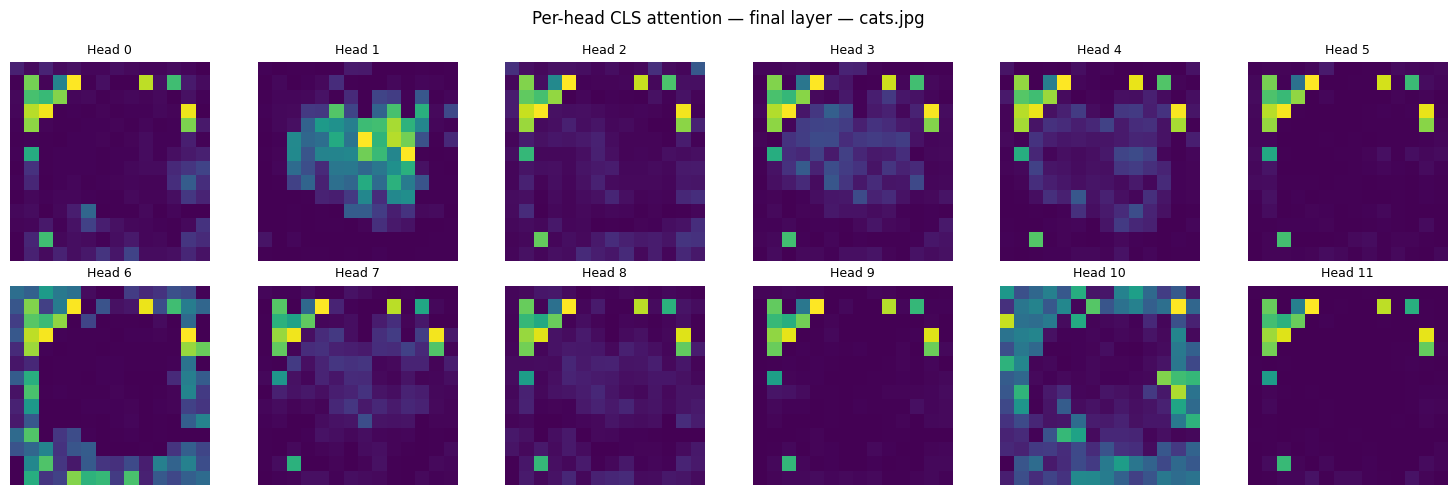

In [36]:
# ============================================================
# Part 3 — Analyze Individual Attention Heads
# ============================================================

import math
import os
import matplotlib.pyplot as plt
import torch


def plot_all_heads(all_attn, name, save_path=None):
    """
    Plot CLS-to-patch attention for every attention head
    in the final transformer layer.

    all_attn:
        tuple of tensors with shape
        (batch, heads, sequence_length, sequence_length)
    """

    # --------------------------------------------------------
    # Final transformer layer
    # --------------------------------------------------------
    last_layer_attn = all_attn[-1][0]
    # Shape: (heads, sequence_length, sequence_length)

    # --------------------------------------------------------
    # CLS token -> patch tokens
    # Token 0 is CLS.
    # Tokens 1: are the 196 image patches.
    # --------------------------------------------------------
    cls_attn = last_layer_attn[:, 0, 1:]
    # Shape: (heads, 196)

    cls_attn = cls_attn.detach().cpu().numpy()

    # --------------------------------------------------------
    # Check dimensions
    # --------------------------------------------------------
    num_heads = cls_attn.shape[0]
    num_patches = cls_attn.shape[1]

    expected_patches = GRID_SIZE * GRID_SIZE

    print(f"\n{name}.jpg")
    print(f"  Number of heads: {num_heads}")
    print(f"  Number of patches: {num_patches}")
    print(f"  Patch grid: {GRID_SIZE} x {GRID_SIZE}")

    if num_patches != expected_patches:
        raise ValueError(
            f"Expected {expected_patches} patches "
            f"({GRID_SIZE}x{GRID_SIZE}), "
            f"but received {num_patches}."
        )

    # --------------------------------------------------------
    # Create 2-row subplot
    # --------------------------------------------------------
    cols = math.ceil(num_heads / 2)

    fig, axes = plt.subplots(
        2,
        cols,
        figsize=(2.5 * cols, 5)
    )

    # Make axes always 1-dimensional
    axes = np.array(axes).reshape(-1)

    # --------------------------------------------------------
    # Plot every head
    # --------------------------------------------------------
    for h in range(num_heads):

        attention_map = cls_attn[h].reshape(
            GRID_SIZE,
            GRID_SIZE
        )

        axes[h].imshow(
            attention_map,
            cmap="viridis"
        )

        axes[h].set_title(
            f"Head {h}",
            fontsize=9
        )

        axes[h].axis("off")

    # Hide unused axes
    for h in range(num_heads, len(axes)):
        axes[h].axis("off")

    plt.suptitle(
        f"Per-head CLS attention — final layer — {name}.jpg",
        fontsize=12
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight"
        )
        print(f"Saved: {save_path}")

    plt.show()


# ============================================================
# Generate plots for all sample images
# ============================================================

if "attention_cache" not in globals():
    raise RuntimeError(
        "attention_cache does not exist. "
        "Please run the Part 2 cell (Cell 16) first."
    )


for name, cached in attention_cache.items():

    all_attn = cached["all_attn"]

    save_path = os.path.join(
        FIG_DIR,
        f"part3_all_heads_{name}.png"
    )

    plot_all_heads(
        all_attn,
        name,
        save_path=save_path
    )

## 6. Data — CIFAR-10 for Parts 4 & 5

Loaded once here and reused by both the masking sweep (Part 4) and the pooling
comparison (Part 5).

In [23]:
cifar_train_full = datasets.CIFAR10(root=CIFAR_DIR, train=True,  download=True, transform=vit_tf)
cifar_test_full  = datasets.CIFAR10(root=CIFAR_DIR, train=False, download=True, transform=vit_tf)
CIFAR10_CLASSES = cifar_train_full.classes

probe_train_idx = list(range(len(cifar_train_full)))
random.Random(SEED).shuffle(probe_train_idx)
probe_train_idx = probe_train_idx[:PROBE_TRAIN_SIZE]

cifar_probe_train_loader = DataLoader(Subset(cifar_train_full, probe_train_idx),
                                       batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
cifar_probe_test_loader  = DataLoader(cifar_test_full,
                                       batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Probe train subset: {len(probe_train_idx)} | Probe test set: {len(cifar_test_full)}")


100%|██████████| 170M/170M [24:35<00:00, 116kB/s]


Probe train subset: 2000 | Probe test set: 10000


## 7. Part 5 — CLS Token vs. Mean-Pooled Patch Tokens

(Done before Part 4 because Part 4's masking sweep reuses the CLS-token probe fit
here on *clean* images.) Extract both pooling variants from the final hidden state,
fit a linear probe on each, and compare test accuracy.

In [37]:
@torch.no_grad()
def extract_vit_embeddings(loader, device, max_samples=None, cache_path=None):
    if cache_path and os.path.exists(cache_path):
        data = np.load(cache_path)
        print(f"Loaded cached embeddings: {cache_path}")
        return data["cls"], data["mean"], data["labels"]

    cls_feats, mean_feats, labels_all = [], [], []
    collected = 0
    model.eval()
    for x, y in loader:
        if max_samples and collected >= max_samples:
            break
        x = x.to(device)
        out = model(pixel_values=x, output_hidden_states=True)
        hidden = out.hidden_states[-1]                     # (B, seq_len, hidden)
        cls_feats.append(hidden[:, 0, :].cpu().numpy())
        mean_feats.append(hidden[:, 1:, :].mean(dim=1).cpu().numpy())
        labels_all.append(y.numpy())
        collected += x.size(0)

    cls_arr = np.concatenate(cls_feats, axis=0)
    mean_arr = np.concatenate(mean_feats, axis=0)
    labels_arr = np.concatenate(labels_all, axis=0)
    if max_samples:
        cls_arr, mean_arr, labels_arr = cls_arr[:max_samples], mean_arr[:max_samples], labels_arr[:max_samples]

    if cache_path:
        np.savez(cache_path, cls=cls_arr, mean=mean_arr, labels=labels_arr)
    return cls_arr, mean_arr, labels_arr


In [38]:
TRAIN_FEAT_CACHE = os.path.join(FEATURE_DIR, "cifar10_train_embeddings.npz")
TEST_FEAT_CACHE  = os.path.join(FEATURE_DIR, "cifar10_test_embeddings.npz")

cls_train, mean_train, y_train = extract_vit_embeddings(
    cifar_probe_train_loader, DEVICE, max_samples=PROBE_TRAIN_SIZE, cache_path=TRAIN_FEAT_CACHE)
cls_test, mean_test, y_test = extract_vit_embeddings(
    cifar_probe_test_loader, DEVICE, max_samples=PROBE_TEST_SIZE, cache_path=TEST_FEAT_CACHE)

print(f"CLS features:  train={cls_train.shape}  test={cls_test.shape}")
print(f"Mean features: train={mean_train.shape} test={mean_test.shape}")


Loaded cached embeddings: /content/drive/MyDrive/ATML_A0/Task2_ViT/features/cifar10_train_embeddings.npz
Loaded cached embeddings: /content/drive/MyDrive/ATML_A0/Task2_ViT/features/cifar10_test_embeddings.npz
CLS features:  train=(2000, 768)  test=(1000, 768)
Mean features: train=(2000, 768) test=(1000, 768)


In [39]:
from sklearn.metrics import accuracy_score

probe_cls  = train_or_load_probe(os.path.join(CKPT_DIR, "probe_cls.joblib"),  cls_train,  y_train)
probe_mean = train_or_load_probe(os.path.join(CKPT_DIR, "probe_mean.joblib"), mean_train, y_train)

acc_cls  = accuracy_score(y_test, probe_cls.predict(cls_test))
acc_mean = accuracy_score(y_test, probe_mean.predict(mean_test))

print(f"Linear probe accuracy — CLS token:         {acc_cls:.4f}")
print(f"Linear probe accuracy — mean-pooled patch: {acc_mean:.4f}")

pd.DataFrame([{"pooling": "cls", "accuracy": acc_cls},
              {"pooling": "mean", "accuracy": acc_mean}]
             ).to_csv(os.path.join(LOG_DIR, "part5_pooling_comparison.csv"), index=False)


Loaded cached probe: /content/drive/MyDrive/ATML_A0/Task2_ViT/checkpoints/probe_cls.joblib
Loaded cached probe: /content/drive/MyDrive/ATML_A0/Task2_ViT/checkpoints/probe_mean.joblib
Linear probe accuracy — CLS token:         0.9520
Linear probe accuracy — mean-pooled patch: 0.9550


## 8. Part 4 — Patch-Masking Experiment

Zero out a fraction of the 16×16 patches (in normalized pixel space, so the fill
value corresponds to the per-channel mean rather than pure black) and evaluate the
**Part 5 CLS-token linear probe** — trained only on clean, unmasked images — on the
masked inputs. This directly measures robustness to missing patches. `random`
masking uses a fresh random pattern per batch (seeded for reproducibility); `center`
masking always removes the patches nearest the grid center.

In [40]:
def make_patch_mask(fraction, strategy, grid_size=GRID_SIZE, seed=0):
    total = grid_size * grid_size
    num_mask = int(round(fraction * total))
    mask = np.ones(total, dtype=bool)   # True = keep, False = mask out
    if num_mask == 0:
        return mask
    if strategy == "random":
        rng = np.random.RandomState(seed)
        idx = rng.choice(total, size=num_mask, replace=False)
    elif strategy == "center":
        coords = np.array([divmod(i, grid_size) for i in range(total)])
        center = (grid_size - 1) / 2
        dist = np.sqrt(((coords - center) ** 2).sum(axis=1))
        idx = np.argsort(dist)[:num_mask]
    else:
        raise ValueError(strategy)
    mask[idx] = False
    return mask


def apply_patch_mask(pixel_values, mask, patch_size=PATCH_SIZE, grid_size=GRID_SIZE, fill_value=0.0):
    pv = pixel_values.clone()
    for p in np.where(~mask)[0]:
        r, c = divmod(int(p), grid_size)
        y0, y1 = r * patch_size, (r + 1) * patch_size
        x0, x1 = c * patch_size, (c + 1) * patch_size
        pv[:, :, y0:y1, x0:x1] = fill_value
    return pv


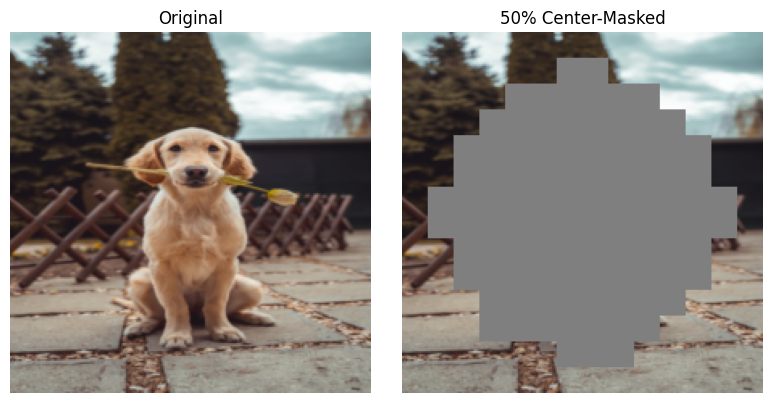

Saved: /content/drive/MyDrive/ATML_A0/Task2_ViT/figures/part4_masking_demo.png


In [41]:
# ============================================================
# Part 4 — Sanity Check: Visualize a Masked Image
# ============================================================

sample_pv = attention_cache["dog"]["pixel_values"]

demo_mask = make_patch_mask(
    fraction=0.5,
    strategy="center"
)

masked_pv = apply_patch_mask(
    sample_pv,
    demo_mask
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

axes[0].imshow(
    unnormalize_for_display(sample_pv[0])
)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(
    unnormalize_for_display(masked_pv[0])
)
axes[1].set_title("50% Center-Masked")
axes[1].axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIG_DIR,
    "part4_masking_demo.png"
)

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {save_path}")

In [42]:
mask_eval_idx = list(range(len(cifar_test_full)))
random.Random(SEED).shuffle(mask_eval_idx)
mask_eval_idx = mask_eval_idx[:MASK_EVAL_SUBSET]
mask_eval_loader = DataLoader(Subset(cifar_test_full, mask_eval_idx),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

MASK_RESULTS_PATH = os.path.join(LOG_DIR, "part4_masking_results.csv")
results_df = load_history(MASK_RESULTS_PATH)

for strategy in MASK_STRATEGIES:
    for fraction in MASK_FRACTIONS:
        if row_already_done(results_df, fraction=fraction, strategy=strategy):
            print(f"[skip] fraction={fraction:.2f} strategy={strategy}: already computed")
            continue

        correct, total = 0, 0
        for batch_idx, (x, y) in enumerate(mask_eval_loader):
            mask = make_patch_mask(fraction, strategy, seed=SEED + batch_idx)
            x_masked = apply_patch_mask(x, mask).to(DEVICE)
            with torch.no_grad():
                out = model(pixel_values=x_masked, output_hidden_states=True)
                cls_feat = out.hidden_states[-1][:, 0, :].cpu().numpy()
            preds = probe_cls.predict(cls_feat)
            correct += int((preds == y.numpy()).sum())
            total += len(y)

        acc = correct / total
        append_history_row(MASK_RESULTS_PATH,
                            {"fraction": fraction, "strategy": strategy, "accuracy": acc, "n_images": total})
        results_df = load_history(MASK_RESULTS_PATH)
        print(f"fraction={fraction:.2f} strategy={strategy:>6}: accuracy={acc:.4f}  (n={total})")

results_df.sort_values(["strategy", "fraction"])


fraction=0.00 strategy=random: accuracy=0.9540  (n=500)
fraction=0.10 strategy=random: accuracy=0.9420  (n=500)
fraction=0.25 strategy=random: accuracy=0.9120  (n=500)
fraction=0.50 strategy=random: accuracy=0.8000  (n=500)
fraction=0.75 strategy=random: accuracy=0.4320  (n=500)
fraction=0.90 strategy=random: accuracy=0.3220  (n=500)
fraction=0.00 strategy=center: accuracy=0.9540  (n=500)
fraction=0.10 strategy=center: accuracy=0.9060  (n=500)
fraction=0.25 strategy=center: accuracy=0.8020  (n=500)
fraction=0.50 strategy=center: accuracy=0.5640  (n=500)
fraction=0.75 strategy=center: accuracy=0.3800  (n=500)
fraction=0.90 strategy=center: accuracy=0.2820  (n=500)


,fraction,strategy,accuracy,n_images
6,0.00,center,0.954,500
7,0.10,center,0.906,500
8,0.25,center,0.802,500
9,0.50,center,0.564,500
10,0.75,center,0.380,500
11,0.90,center,0.282,500
0,0.00,random,0.954,500
1,0.10,random,0.942,500
2,0.25,random,0.912,500
3,0.50,random,0.800,500


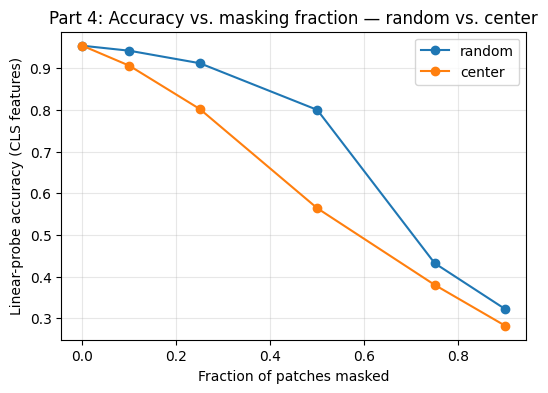

In [43]:
plt.figure(figsize=(6, 4))
for strategy in MASK_STRATEGIES:
    sub = results_df[results_df["strategy"] == strategy].sort_values("fraction")
    plt.plot(sub["fraction"], sub["accuracy"], marker="o", label=strategy)
plt.xlabel("Fraction of patches masked")
plt.ylabel("Linear-probe accuracy (CLS features)")
plt.title("Part 4: Accuracy vs. masking fraction — random vs. center")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(os.path.join(FIG_DIR, "part4_masking_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()
